In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn import svm

In [8]:
df = pd.read_csv("../data/processed/train_ohe.csv")
df

,amt,city_pop,is_fraud,hour,age,distance,mean_amt,amt_std,distance_from_prev,time_since_prev_transaction_hours,...,state_WA,state_WI,state_WV,state_WY,week_day_Monday,week_day_Saturday,week_day_Sunday,week_day_Thursday,week_day_Tuesday,week_day_Wednesday
0,7.27,1645,0,12,33,127.606419,56.023366,122.632635,0.000000,0.083333,...,False,False,False,True,False,False,False,False,True,False
1,52.94,1645,0,8,33,110.309077,56.023366,122.632635,224.769536,19.961667,...,False,False,False,True,False,False,False,False,False,True
2,82.08,1645,0,8,33,21.787292,56.023366,122.632635,105.220587,0.044167,...,False,False,False,True,False,False,False,False,False,True
3,34.79,1645,0,12,33,87.204338,56.023366,122.632635,88.152407,3.843889,...,False,False,False,True,False,False,False,False,False,True
4,27.18,1645,0,13,33,74.213070,56.023366,122.632635,132.876960,0.542222,...,False,False,False,True,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296670,60.47,532,0,21,64,78.492673,67.843832,157.223610,72.134080,8.538889,...,False,False,False,False,False,True,False,False,False,False
1296671,74.29,532,0,0,64,55.400846,67.843832,157.223610,50.128303,3.600556,...,False,False,False,False,False,False,True,False,False,False
1296672,246.56,532,0,2,64,115.674563,67.843832,157.223610,94.204046,2.116111,...,False,False,False,False,False,False,True,False,False,False
1296673,2.62,532,0,8,64,60.513482,67.843832,157.223610,61.101300,5.274722,...,False,False,False,False,False,False,True,False,False,False


In [9]:
def get_num_columns(df):
       dtypes_df = pd.DataFrame(df.dtypes).reset_index()
       num_cols = list(dtypes_df[dtypes_df[0] != bool]["index"].values)
       return num_cols

num_cols = get_num_columns(df)
num_cols.remove("is_fraud")

In [10]:
X = df.drop(columns=["is_fraud"])
y = df["is_fraud"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4, stratify=y)
print(X_train.shape, y_train.shape)

(1037340, 81) (1037340,)


In [11]:
scaler = RobustScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.fit_transform(X_test[num_cols])

In [12]:
model = svm.LinearSVC()
# model = LogisticRegression(class_weight="balanced", max_iter=1000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

In [20]:
def get_scores(model, X_test, y_test, target_precision=0.9):
    try:
        y_pred_prob = model.predict_proba(X_test)[:, 1]
    except:
        y_pred_prob = model.decision_function(X_test)
    roc_auc = roc_auc_score(y_test, y_pred_prob)
    pr_auc = average_precision_score(y_test, y_pred_prob)

    precision, recall, thresholds = precision_recall_curve(y_test, y_pred_prob)

    

    # find indices where precision >= target
    valid_idx = np.where(precision >= target_precision)[0]

    if len(valid_idx) > 0:
        best_recall = recall[valid_idx].max()
    else:
        best_recall = 0.0

    print(f"roc_auc: {roc_auc}, pr_auc: {pr_auc}, best_recall: {best_recall}")
    return roc_auc, pr_auc, best_recall, precision, recall


def draw_confusion_matrix(model, X_test,threshold=0.8):
    try:
        y_pred_proba = model.predict_proba(X_test)[:, 1]
    except:
        y_pred_proba = model.decision_function(X_test)
    y_pred = (y_pred_proba >= threshold).astype(int)
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
    plt.show()
    

In [17]:
roc_auc, pr_auc, best_recall, precision, recall = get_scores(model, X_test, y_test, target_precision=0.9)


roc_auc: 0.8654908533689958, pr_auc: 0.3359435889731277, best_recall: 0.08527648234510327


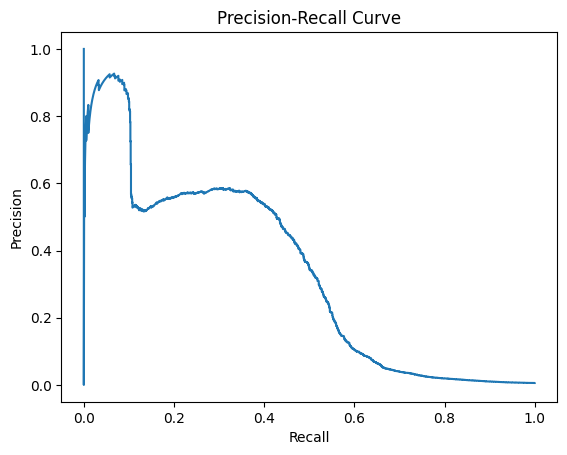

In [18]:

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

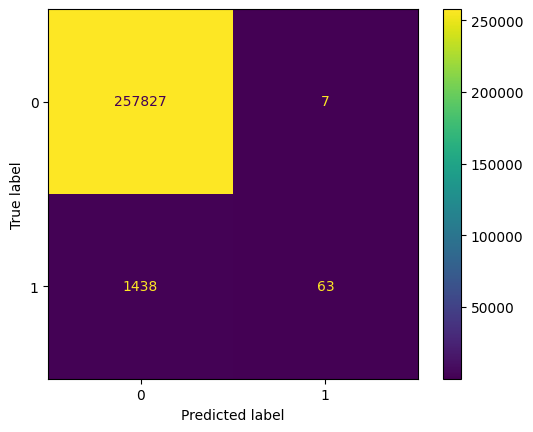

In [21]:
draw_confusion_matrix(model, X_test)

0.2044632997897633
